# Final Project Part 1

### Name: Mykhailo Pipchenko

### eid: mp55327

# Section 1: Introduction & Model Selection

I am part of Longhorn Racing here at UT, and therefore I thought it makes sense for me to analazy the Spring-Mass System (Option A)

I will be using the Spring-Mass system to model the front quarter-car suspension of high-performance race car, similar to an FSAE car we build at Longhorn Racing. The point of a quarter-car model is to isolate one corner of a vehicle for the purpose of analyzing the vehicle dynamics independently. A quarter-car model is also much simpler and easier to work with, as full multi-body dynamics models often get too complicated. The scenario that this project will cover is one of a vehicle striking a curb or bump, which singificantly activates the suspension and moves the unsprung mass. Basically, I will be modeling the response of the chassis, as the spring and shock dissipate the energy, and the suspension and unsprung mass of the car return to it's static position.

The system is mechanical, so it's covered by Newton's 2nd Law. One can get this second-order ordinary differential equation after summing the vertical forces: 

$$m \frac{d^2y}{dt^2} + c \frac{dy}{dt} + k y = 0$$

To actually use numerical solver methods to get any soltuions to the equation, it needs to be converted to a first-order system. To convert the second-order ODE, 2 state variables need to be defined (position and velocity):

* Let's let $y_1 = y(t)$ (Position)
* and $y_2 = \frac{dy}{dt}$ (Velocity)

Taking the derivative of $y_1$ gives the first equation:
$$\frac{dy_1}{dt} = y_2$$

Taking the derivative of $y_2$ (which is acceleration, $\frac{d^2y}{dt^2}$) and rearranging ODE to solve for the highest derivative gives:
$$\frac{dy_2}{dt} = -\frac{c}{m}y_2 - \frac{k}{m}y_1$$

This provides the required system of two first-order ODEs:
$$\begin{bmatrix} y_1' \\ y_2' \end{bmatrix} = \begin{bmatrix} y_2 \\ -\frac{c}{m}y_2 - \frac{k}{m}y_1 \end{bmatrix}$$

Here is what each variable means:

1. **$m$ (Sprung Mass, kg):** The part of the whole mass of the car that the suspension supports at one corner. Does not include the wheel, tire, brakes, etc.
2. **$k$ (Spring Constant, N/m):** The stiffness of the suspension spring, which governs the force that is needed to compress the suspension.
3. **$c$ (Damping Coefficient, N·s/m):** The energy dissaption rate from the shock. Resists suspension movememnt.
4. **$y(t)$ (Displacement, m):** The vertical position of the sprung mass relative to its static, uncompressed state.
5. **$y'(t)$ or $y_2$ (Velocity, m/s):** The vertical speed of the sprung mass.

# Section 2: Parameter Research & Justification


### Physical Scenario:

The scenario is about a formula-style car driving over a curb. The simulation begins at time $t = 0$, capturing the exact moment the suspension achieves maximum compression over the bump ($5\text{ cm}$). The system tracks the free-viabration response as the spring provides the restoring force and the shock dampens the oscillation, returning the cahssis to its original position.


Parameters were selected to represent a highly tuned, underdamped FSAE vehicle, ensuring optimal tire contact patch load variation.

The parameters were selected around an FSAE vehicle, and I used the textbook titled "Race Car Vehicle Dymanics" by by William Milliken and Douglas Milliken, which is a resource we use to do vehicle dynamics at Longhorn Racing.

### Parameters:
    
Sprung mass: 75 kg. 

Source: Milliken & Milliken, Race Car Vehicle Dynamics (Ch. 18).

Justification: A typical lightweight formula car (such as an FSAE car) has a total mass of roughly 250–300 kg (with the  driver). Removing the unsprung mass (wheels, tires, uprights) and dividing by four corners leads to a standard sprung mass of approximately 75 kg per corner.

Spring Constant (𝑘): 25000 N/m

Source: Milliken & Milliken (Ch. 16).

Justification: These are the springs usually used to target a rid frequence of 2.5 to 3.0 Hz, which is best for race cars.

Damping Coefficient (𝑐): 1650 N*s/m

Source: Milliken & Milliken (Ch. 22).

Justification: Race car's usually perform best with a damping ratio around 0.6. This is the coefficient that is needed to achieve the ratio

### Initial conditions:

1. **Initial Displacement ($y_1(0) = 0.05\text{ m}$):** Represents the vehicle striking a curb, resulting in upward displacement of the suspension.
2. **Initial Velocity ($y_2(0) = 0\text{ m/s}$):** At the absolute peak of the curb (maximum suspension compression), the vertical velocity of the chassis is zero before the suspension begins to extend.

Reference:
Milliken, W. F., & Milliken, D. L. (1995). Race Car Vehicle Dynamics. SAE International.

# Section 3: Numerical Methods Implementation

First the Euler's forward method:

In [21]:
import numpy as np
import matplotlib.pyplot as plt


# the function is built so solve a systme of ODEs using euler's forward
# y0 represents the array of initial conditions, and t is the array of time steps

def euler_forward(f, y0, t):
    
    # emptry 2d array to store results
    Y = np.zeros((len(t), len(y0)))
    
    # initial condition
    Y[0] = y0
    
    for i in range(len(t) - 1):
        # figuring out the step size
        h = t[i+1] - t[i] 
        
        # the actual euler forward formula
        Y[i+1] = Y[i] + h * f(t[i], Y[i])
        
    return Y

Now the the Fourth-Order Runge-Kutta Method:

In [22]:
def rk4(f, y0, t):
    
# this function also times an array of initial conditions and time steps, just like euler forward
    
    #array to store the results
    Y = np.zeros((len(t), len(y0)))
    
    # Set the first row to our initial conditions
    Y[0] = y0
    
    for i in range(len(t) - 1):
        #step size
        h = t[i+1] - t[i]
        
        t_curr = t[i]
        y_curr = Y[i]
        
        # finding the four intermediate slopes
        k1 = h * f(t_curr, y_curr)                              
        k2 = h * f(t_curr + h/2, y_curr + k1/2)              
        k3 = h * f(t_curr + h/2, y_curr + k2/2)             
        k4 = h * f(t_curr + h, y_curr + k3)             
        
        # weighted average RK4 formula
        Y[i+1] = y_curr + (k1 + 2*k2 + 2*k3 + k4) / 6  
        
    return Y

I also need a function that actually defines the system of ODEs

In [23]:
def suspension_ode(t, y):

    # from section 2
    m = 75.0
    k = 25000.0
    c = 1650.0
    
    # the first order equations from section 1
    dy1_dt = y[1]
    dy2_dt = -(c/m) * y[1] - (k/m) * y[0]
    
    return np.array([dy1_dt, dy2_dt])

# Section 4: Solutions & Comparison

### Simulation Setup

To figure out the performance of both methods, the quarter car suspension model will need to be simulated from t = 0 to t = 1.5 seconds. Usually, a proper race car returns to a static position after hitting a curb/bump in about this time. 

Here are the three step sizes used:

h = 0.01s

h = 0.05s

h = 0.1s

In [24]:
t_end = 1.5
step_sizes = [0.01, 0.05, 0.1]

#initial displacement and velocity
y0 = np.array([0.05, 0.0])

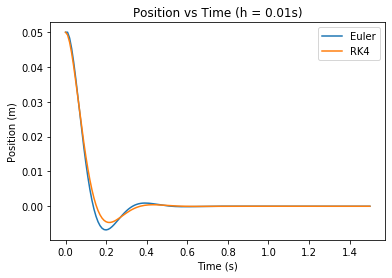

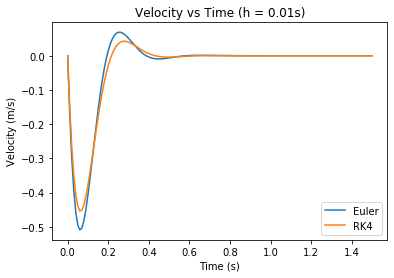

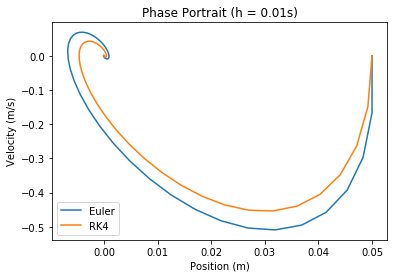

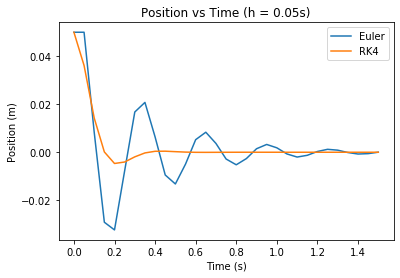

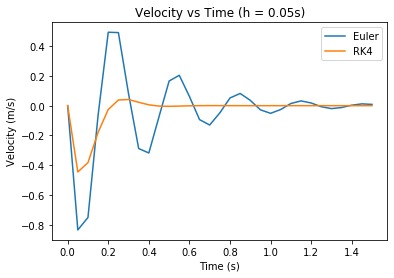

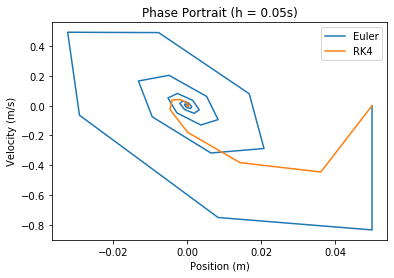

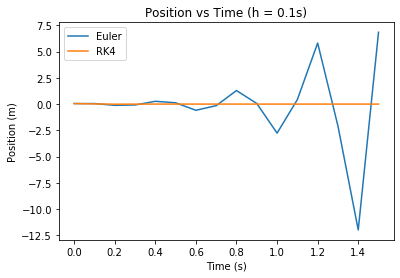

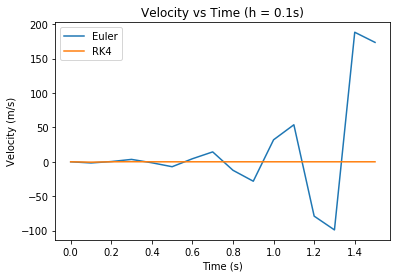

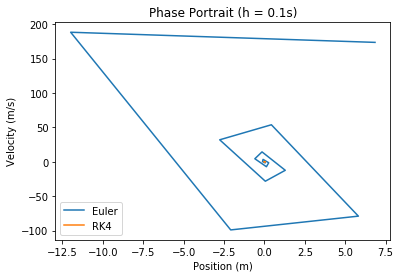

In [25]:
for h in step_sizes:
    # time array for current step size
    t_eval = np.arange(0, t_end + h, h)
    
    # running the solvers
    Y_euler = euler_forward(suspension_ode, y0, t_eval)
    Y_rk4 = rk4(suspension_ode, y0, t_eval)
    
    # data for plotting
    pos_euler = Y_euler[:, 0]
    vel_euler = Y_euler[:, 1]
    
    pos_rk4 = Y_rk4[:, 0]
    vel_rk4 = Y_rk4[:, 1]
    
    # Plot 1: Position vs. Time
    plt.figure()
    plt.plot(t_eval, pos_euler, label="Euler")
    plt.plot(t_eval, pos_rk4, label="RK4")
    plt.title(f"Position vs Time (h = {h}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Position (m)")
    plt.legend()
    plt.show()
    
    # Plot 2: Velocity vs. Time
    plt.figure()
    plt.plot(t_eval, vel_euler, label="Euler")
    plt.plot(t_eval, vel_rk4, label="RK4")
    plt.title(f"Velocity vs Time (h = {h}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.legend()
    plt.show()
    
    # Plot 3: Phase Portrait 
    plt.figure()
    plt.plot(pos_euler, vel_euler, label="Euler")
    plt.plot(pos_rk4, vel_rk4, label="RK4")
    plt.title(f"Phase Portrait (h = {h}s)")
    plt.xlabel("Position (m)")
    plt.ylabel("Velocity (m/s)")
    plt.legend()
    plt.show()

### Discussion of visual differences:

For h = 0.01:
Both methods overlap and produce almost identical results. The position and velocity curves show smooth decay, which is how a damper should behave. The phase portrait shows an inward spiral, which looks good.

For h = 0.05:
RK4 still performs decent, while Euler Forward begins to struggle. Euler overshoots displacement and velocity peaks, going slightly out of control. The euler phase portrait goes out of control and does spiral inward cleanly.,


For h = 0.1:
Euler becomes unstable and fails, causing the calculated position to oscillate wildly. This makes the Y axis very large, and shows RK4 as a flat line, while it in fact still perfroms well. The phase portrait properly shows euler exploding outward, while RK4 looks as a point, still remaining robust.

# Section 5: Stability Analysis

### Stable vs. Unstable Behavior + Demonstration of Limits:
As seen by the results from section 4, the euler method has a very strict stability method. It remains stable for h = 0.01s and starts osciallating too much and overshooting for h = 0.05s. For h = 0.1s, Euler completely exceeds its stability limit and that leads to unstable behavior. RK4, on the other hand, handles all the step sizes well.

### Physical Interpretation
The quarter-car model is just a damped mechanical system, which means that the suspension should dissipate the energy and return to 0 over time. Euler becomes unstable at h = 0.1, and leads to a non-physical result, never returning to zero. Instead of decaying, the solution grows. The numerical instability of euler at h = 0.1, creates a scenario where the damper adds energy instead of removing it. RK4 performs properly, and shows the energy dissipating and then returns to 0. Euler also is physically correct for h = 0.01, and slightly unstable and overshoots the values for h = 0.05.

In [26]:
m = 75.0
k = 25000.0
c = 1650.0

omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(k * m))
omega_d = omega_n * np.sqrt(1 - zeta**2)

In [27]:
def exact_solution(t):
    return 0.05 * np.exp(-zeta * omega_n * t) * (np.cos(omega_d * t) + (zeta * omega_n / omega_d) * np.sin(omega_d * t))

h_values = [0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
euler_errors = []
rk4_errors = []

y0 = np.array([0.05, 0.0])

Euler Slope: 1.1613772260083743
RK4 Slope: 4.058441012268184


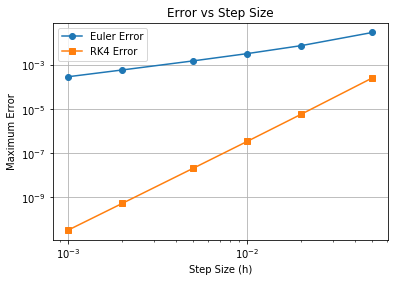

In [28]:
for h in h_values:
    t_eval = np.arange(0, 1.0 + h, h)
    
    Y_euler = euler_forward(suspension_ode, y0, t_eval)
    Y_rk4 = rk4(suspension_ode, y0, t_eval)
    
    y_exact = exact_solution(t_eval)
    
    err_euler = np.max(np.abs(Y_euler[:, 0] - y_exact))
    err_rk4 = np.max(np.abs(Y_rk4[:, 0] - y_exact))
    
    euler_errors.append(err_euler)
    rk4_errors.append(err_rk4)

euler_fit = np.polyfit(np.log(h_values), np.log(euler_errors), 1)
rk4_fit = np.polyfit(np.log(h_values), np.log(rk4_errors), 1)

print("Euler Slope:", euler_fit[0])
print("RK4 Slope:", rk4_fit[0])

plt.figure()
plt.loglog(h_values, euler_errors, marker='o', label="Euler Error")
plt.loglog(h_values, rk4_errors, marker='s', label="RK4 Error")
plt.title("Error vs Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Maximum Error")
plt.legend()
plt.grid(True)
plt.show()

### Error analysis and convergence

The log log plot confirms the theoretical convergence rates for both numerical methods. For Eulers method the calculated slope is 1.16 which verifies that it is a first order method where the error is proportional to the step size h. For the RK4 method the calculated slope is 4.06 properly verifying it as a fourth order method where the error is proportional to the step size h to the fourth power.

# Section 6: Conclusions

### Method Performance

RK4 did much better than Euler's Forward method. Euler broke with a higher step size and lead to incorrect physics, making it seem as if new energy was added to the system, never going back to zero. RK4 though, remained completely stable and mathematically accurate across all tested step sizes.

### Computational Cost vs. Accuracy

Euler requires 1 calculation per step, RK4 requires 4. RK4 is able to perform well for larger step sizes without converging, making it actually cheaper computationally when doing high accuracy simulations.

### Practical Recommendations

I would only use RK4 for a spring mass system and all the suspension dynamics/kinematics we do at Longhorn Racing. Euler's low stability limits make it mathematically unsafe for evaluating underdamped FSAE shock absorbers.

### Lessons Learned

Numerical instability leads to physically impossible behavior, like a damper generating artificial energy, which doesn't make any sense. I think it's important to verify mathematical stability limits before trusting any simulation data.